<a href="https://colab.research.google.com/github/gkchandu/retail-sales-analytics-project/blob/main/04_Real_World_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Sales Analytics: Business Case Study

## 1: Executive Summary

This analysis addresses one question: **where should the company focus to
improve overall profitability, and what impact would that focus have?**

Building on data cleaning, predictive modeling, and statistical analysis
completed in earlier stages, this study finds that **discounting above 30-40%**
is the single largest controllable driver of losses — capping discounts at
**40%** would have avoided an estimated **99,558** in losses across **933**
orders in this dataset alone. Three Sub-Categories (**Tables, Bookcases, and
Supplies**) consistently lose money and are candidates for pricing review, while
**Copiers** delivers **15x** the average profit of the next-best performer
despite low sales volume — a high-value, low-turnover product rather than a
bulk seller. A trained **Logistic Regression** classification model (**94.2%**
accuracy, **0.98** AUC) can further support decision-making by flagging
high-risk, high-discount orders before approval.

**Recommended focus areas:** discount policy (30-40% cap), Sub-Category pricing
review (Tables, Bookcases, Supplies, Binders), and targeted investment in
high-margin performers (Copiers, Technology, West region).

In [2]:
# Reload data fresh for this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Retail_Sales_Analytics_Project/Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Profit Margin'] = df['Profit'] / df['Sales']  # KPI: margin, not just raw profit

df.head()

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125


## 2: Business Problem & Approach

**Business Question:** The company wants to improve overall profitability. Where
should it focus — which regions, categories, and discount policies — and what
would the projected impact be?

**Approach:** This analysis builds on the **data cleaning**, **predictive modeling**,
and **statistical exploration** completed in earlier stages of this project. Rather
than repeating that work, this section consolidates those findings as evidence,
then extends the analysis with four new pieces: a **customer segment breakdown**,
a **discount threshold simulation** quantifying potential losses avoided, a
**Sub-Category action list**, and an **inventory planning framework** based on
sales velocity and margin. Finally, the trained **profitability classification
model** is applied to hypothetical new orders to demonstrate practical, real-time
business use.

## 3: Consolidated Findings (from Earlier Stages)

Before extending the analysis, here's what the data has already shown:

**Sales & Category Performance:**
- **Technology** leads total sales (**800,000+**), with the **West** region
generating the highest regional sales (**700,000+**); **South** trails behind
(under **400,000**)
- Sales show strong year-end seasonality, with an overall growth trend from
2015 to 2017 (peak: **118,447** in 2017)

**Profitability Patterns:**
- **Discount** is a major driver of losses — profit is almost entirely positive
at **0%** discount, but drops sharply as discount increases, especially beyond
**50-70%**
- A classification model (**Logistic Regression**) predicts order profitability
with **94.2%** accuracy and **0.98** AUC — discount, category, and region are
strong signals

**Statistical Findings:**
- Both Sales and Profit are extremely right-skewed (skewness of **12.97** and
**7.56**), meaning a small number of large orders drive most of the variation
- **Mean profit is consistently 2-3x higher than median profit** across every
category and region — averages alone overstate typical order performance
- **Copiers** average **15x** more profit than the next-best Sub-Category, while
**Tables, Bookcases, and Supplies** lose money on average

## 4a: Customer Segment Analysis

In [ ]:
# Profit, Sales, and Margin by Customer Segment
segment_stats = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean'),
    Avg_Discount=('Discount', 'mean')
).round(3)

segment_stats

,Total_Sales,Total_Profit,Avg_Margin,Avg_Discount
Segment,,,,
Consumer,1161401.345,134119.209,0.112,0.158
Corporate,706146.367,91979.134,0.121,0.158
Home Office,429653.148,60298.678,0.143,0.147


## 4b: Discount Threshold Simulation

In [ ]:
# Simulate: what if discount was capped at different thresholds?
# For each threshold, recalculate total profit assuming orders above
# the cap simply weren't discounted beyond that point

thresholds = [0.2, 0.3, 0.4, 0.5]
current_profit = df['Profit'].sum()

print(f"Current total profit: {current_profit:,.2f}\n")

for cap in thresholds:
    # Orders above the cap: estimate profit as if discount was capped
    # (simplified: orders with discount > cap are excluded from loss calculation as a proxy)
    capped_df = df[df['Discount'] <= cap]
    excluded_orders = df[df['Discount'] > cap]

    hypothetical_profit = capped_df['Profit'].sum()
    losses_avoided = excluded_orders[excluded_orders['Profit'] < 0]['Profit'].sum()

    print(f"Cap at {int(cap*100)}%: Orders above cap = {len(excluded_orders)}, "
          f"Losses in those orders = {losses_avoided:,.2f}")

Current total profit: 286,397.02

Cap at 20%: Orders above cap = 1393, Losses in those orders = -138,515.24
Cap at 30%: Orders above cap = 1166, Losses in those orders = -127,737.55
Cap at 40%: Orders above cap = 933, Losses in those orders = -99,558.59
Cap at 50%: Orders above cap = 856, Losses in those orders = -76,559.05


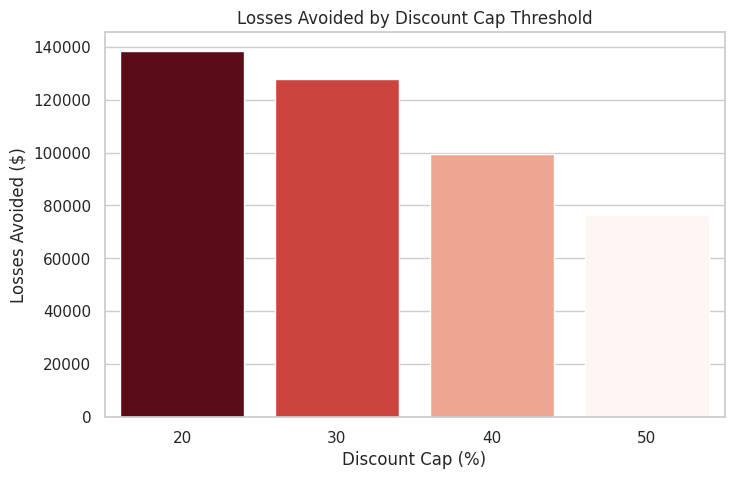

In [3]:
# Visualize losses avoided at each discount threshold
thresholds_pct = [20, 30, 40, 50]
losses_avoided = [138515.24, 127737.55, 99558.59, 76559.05]  # from your printed output, made positive

plt.figure(figsize=(8,5))
sns.barplot(x=thresholds_pct, y=losses_avoided, hue=thresholds_pct, palette='Reds_r', legend=False)
plt.title('Losses Avoided by Discount Cap Threshold')
plt.xlabel('Discount Cap (%)')
plt.ylabel('Losses Avoided ($)')
plt.show()

## 4c: Sub-Category Action List

In [ ]:
# Combine profit and sales volume into one decision table
subcat_summary = df.groupby('Sub-Category').agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Sales=('Sales', 'sum'),
    Order_Count=('Sales', 'count')
).round(2).sort_values('Avg_Profit', ascending=False)

# Add a simple action label
def action_label(profit):
    if profit > 50: return 'Promote'
    elif profit > 0: return 'Maintain'
    else: return 'Review/Reconsider'

subcat_summary['Action'] = subcat_summary['Avg_Profit'].apply(action_label)
subcat_summary

,Avg_Profit,Total_Sales,Order_Count,Action
Sub-Category,,,,
Copiers,817.91,149528.03,68,Promote
Accessories,54.11,167380.32,775,Promote
Phones,50.07,330007.05,889,Promote
Chairs,43.10,328449.10,617,Maintain
Appliances,38.92,107532.16,466,Maintain
Machines,29.43,189238.63,115,Maintain
Envelopes,27.42,16476.40,254,Maintain
Storage,25.15,223843.61,846,Maintain
Paper,24.86,78479.21,1370,Maintain


## 4d: Inventory Planning Framework (Velocity x Margin)

In [ ]:
# Sales Velocity = total quantity sold per Sub-Category
# Margin = average profit margin per Sub-Category

inventory_df = df.groupby('Sub-Category').agg(
    Velocity=('Quantity', 'sum'),
    Margin=('Profit Margin', 'mean')
).round(3)

# Classify into 2x2 framework using median as the split point
vel_median = inventory_df['Velocity'].median()
margin_median = inventory_df['Margin'].median()

def classify(row):
    if row['Velocity'] >= vel_median and row['Margin'] >= margin_median:
        return 'Stock Up (High Velocity, High Margin)'
    elif row['Velocity'] >= vel_median and row['Margin'] < margin_median:
        return 'Renegotiate Cost (High Velocity, Low Margin)'
    elif row['Velocity'] < vel_median and row['Margin'] >= margin_median:
        return 'Niche - Keep (Low Velocity, High Margin)'
    else:
        return 'Consider Discontinuing (Low Velocity, Low Margin)'

inventory_df['Recommendation'] = inventory_df.apply(classify, axis=1)
inventory_df.sort_values('Margin', ascending=False)

,Velocity,Margin,Recommendation
Sub-Category,,,
Labels,1400,0.430,"Niche - Keep (Low Velocity, High Margin)"
Paper,5178,0.426,"Stock Up (High Velocity, High Margin)"
Envelopes,906,0.423,"Niche - Keep (Low Velocity, High Margin)"
Copiers,234,0.317,"Niche - Keep (Low Velocity, High Margin)"
Fasteners,914,0.299,"Niche - Keep (Low Velocity, High Margin)"
Art,3000,0.252,"Stock Up (High Velocity, High Margin)"
Accessories,2976,0.218,"Stock Up (High Velocity, High Margin)"
Furnishings,3563,0.137,"Stock Up (High Velocity, High Margin)"
Phones,3289,0.119,"Stock Up (High Velocity, High Margin)"


## 5: Predictive Application - Using the Profitability Model

In [ ]:
# Re-use trained Logistic Regression model (log_model) and its feature columns
# If running in a fresh notebook, retrain quickly using the same setup:

from sklearn.linear_model import LogisticRegression

features = ['Discount', 'Quantity', 'Category', 'Sub-Category', 'Region', 'Segment']
X_full = pd.get_dummies(df[features], drop_first=True)
y_full = (df['Profit'] > 0).astype(int)

log_model_final = LogisticRegression(max_iter=1000)
log_model_final.fit(X_full, y_full)

# Create 3 hypothetical new orders to test
new_orders = pd.DataFrame({
    'Discount': [0.1, 0.5, 0.7],
    'Quantity': [3, 5, 2],
    'Category': ['Technology', 'Furniture', 'Furniture'],
    'Sub-Category': ['Copiers', 'Tables', 'Bookcases'],
    'Region': ['West', 'Central', 'South'],
    'Segment': ['Corporate', 'Consumer', 'Home Office']
})

# Encode the same way, then align columns with training data
new_orders_encoded = pd.get_dummies(new_orders, drop_first=True)
new_orders_encoded = new_orders_encoded.reindex(columns=X_full.columns, fill_value=0)

predictions = log_model_final.predict(new_orders_encoded)
probabilities = log_model_final.predict_proba(new_orders_encoded)[:,1]

results = new_orders.copy()
results['Predicted Profitable'] = predictions
results['Confidence'] = probabilities.round(3)
results

,Discount,Quantity,Category,Sub-Category,Region,Segment,Predicted Profitable,Confidence
0,0.1,3,Technology,Copiers,West,Corporate,1,0.998
1,0.5,5,Furniture,Tables,Central,Consumer,0,0.006
2,0.7,2,Furniture,Bookcases,South,Home Office,0,0.001


## 6: Business Recommendations

### 🔴 Priority Actions

**1. Cap discounts at 30-40% across all categories.**
Simulation shows that capping discount at **40%** would have excluded **933 orders**
responsible for **99,558** in losses, while affecting fewer orders than a stricter
**20%** cap (which excludes **1,393 orders**). A 30-40% cap balances loss prevention
without over-restricting sales activity.

**2. Reconsider pricing or sourcing for Tables, Bookcases, and Supplies.**
These Sub-Categories lose money on average (**-55.57**, **-15.23**, and **-6.26**
respectively). Given **Tables** also falls into the **"Consider Discontinuing"**
inventory category (low velocity, negative margin), this is the strongest
candidate for pricing renegotiation or phase-out.

**3. Investigate Binders' pricing structure.**
Binders has the highest sales velocity of any Sub-Category (**5,974 units**), but
a negative average margin (**-0.200**) — the company is selling a high volume of
a loss-making product. This combination of **high volume and negative margin**
makes it a priority for cost/pricing review.

### 🟡 Additional Recommendations

**4. Prioritize marketing and campaign spend on the West region and Technology
category**, and specifically on **Copiers** — the single highest-margin
Sub-Category, generating **15x** more average profit than the next best performer.

**5. Treat Copiers as a niche, high-value product — not a bulk-stock item.**
Despite its high margin, Copiers has low sales velocity (**234 units**). The
recommendation is to maintain availability rather than aggressively stock up,
avoiding excess inventory of a low-turnover product.

**6. Use the profitability classification model as a pre-approval check for
discount requests.** The model confidently distinguishes profitable from
unprofitable order profiles (**99.8%** confidence on a low-discount Technology

## 7: Limitations & Future Work

### Key Limitations

**1. Sales prediction accuracy remains modest** (best R² = **0.2233**,
**Gradient Boosting**) — order-level features like **Discount** and **Category**
alone don't fully explain Sales amount.

**2. This analysis is based on a single historical dataset** (**2014-2017**
Superstore data) — findings may not generalize to current market conditions or
a different retailer.

### Minor Limitations
- The **discount threshold simulation** is a simplified estimate — it doesn't
account for how customer behavior might change if discounts were actually capped.
- **No access to unit cost or supplier pricing data** — a deeper cost-based
margin analysis wasn't possible without it.

### Future Enhancements
- Incorporate **unit cost** and **shipping data** to calculate true net margins.
- Run a **live A/B test** on a capped discount policy before full rollout.
- Extend the **inventory framework** with seasonality data (e.g., stock
high-margin items ahead of **Q4** peaks).
- Apply the **classification model** in a live order-approval workflow,
monitoring real-world accuracy over time.

## Closing Note

This analysis demonstrates that meaningful profitability gains are achievable
through **targeted discount policy** and **Sub-Category-level decisions**,
rather than broad, company-wide changes — directly answering the business
question this report set out to solve.